<a href="https://colab.research.google.com/github/theyasassri/Ames-Housing-Price-Prediction/blob/main/HousePriceData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##My project 2 :    
#House Pricing Prediction Analysis

Target :- Predicting House Prices
(describing data
to **Predictive Modeling**)

Case Study :- Predicting Real estate Value with Machine learning
project type :- Regression Analysis
Goal :- Build a predictive model to estimate hosue prices with an error margin of less than $30k.

###  Project Overview
In this analysis, I moved from simple exploration to **Predictive Modeling**. I used the Ames Housing Dataset to identify the physical features that drive house prices and built a Linear Regression model to automate price estimations.

###  Key Technical Skills Used:
**Feature Engineering:** Combining separate area measurements into a single 'TotalSF' metric.

 **Smart Imputation:** Handling missing values based on domain logic (e.g., 'No Pool' vs. 'Missing Data').

 **Machine Learning:** Training a Linear Regression model and evaluating it using Mean Absolute Error (MAE).

Target :- SalePrice

##1. Introduction

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path

from ames_house_prices.data import load_training_data

df_house = load_training_data(Path("train.csv"))

In [7]:
print(df_house.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df_house.shape

(1460, 81)

In [9]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

##2. Heatmap
instead of checking one column at a time, we need to see which columns have "the strongest pulse"
relate to the sales price.

So for better results for my project I used a correlation heatmap tp identfy my "power Features."


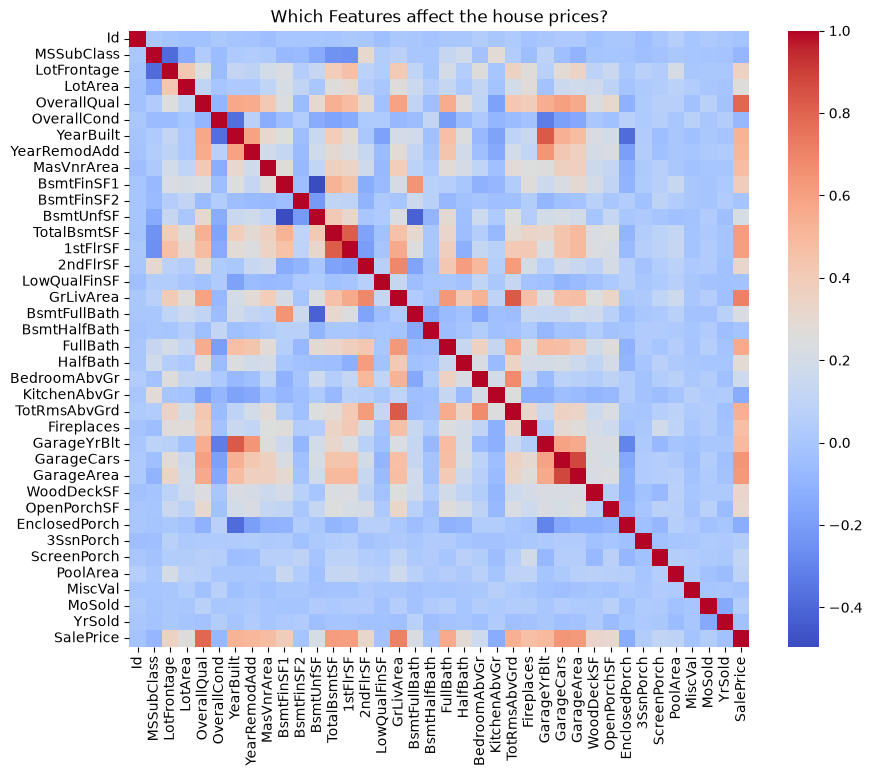

In [10]:
#Only taking columns which datatype is "number"
num_df=df_house.select_dtypes(include=['number'])

#This will check how much each variable relates to SalePrice
correlations = num_df.corr()

#Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, cmap='coolwarm',annot=False)
plt.title('Which Features affect the house prices?')
plt.show()

The "OverallQual" score(Salesprice): 0.8

The "GrLivArea"(Ground living area)(Salesprice): more like 0.7

I discovered that Quality (0.8) and Size (0.7) are the primary drivers of price.


In [11]:
#Missing Data
df_house.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [12]:
col_to_fix = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu']
for col in col_to_fix:
  df_house[col] = df_house[col].fillna('None')

df_house['LotFrontage'] = df_house['LotFrontage'].fillna(df_house['LotFrontage'].median())

print(df_house[['PoolQC','LotFrontage']].isnull().sum())

PoolQC         0
LotFrontage    0
dtype: int64


##3. Data Cleaning & Strategic Imputation

To ensure the integrity of the predictive model, I performed a two-step imputation process to handle missing values without sacrificing valuable data. First, I addressed Categorical Missingness in features like PoolQC and FireplaceQu; rather than deleting these rows, I filled the null values with 'None', correctly identifying that a missing entry represented the absence of a feature (e.g., no pool) rather than a recording error. Second, for Numerical Missingness in LotFrontage, I utilized Median Imputation to fill gaps with the typical street-connection value for the dataset. This approach prevented the loss of nearly 90% of the observations and allowed the model to leverage 'the absence of a feature' as a meaningful predictor of house value.

##4.Regression plot
I used this to visualize the relationship between house size(GrLivArea) and price.
And of course,the chart identify the outliers and confirmed a linear relationship.(as size goes up the price goes up too)

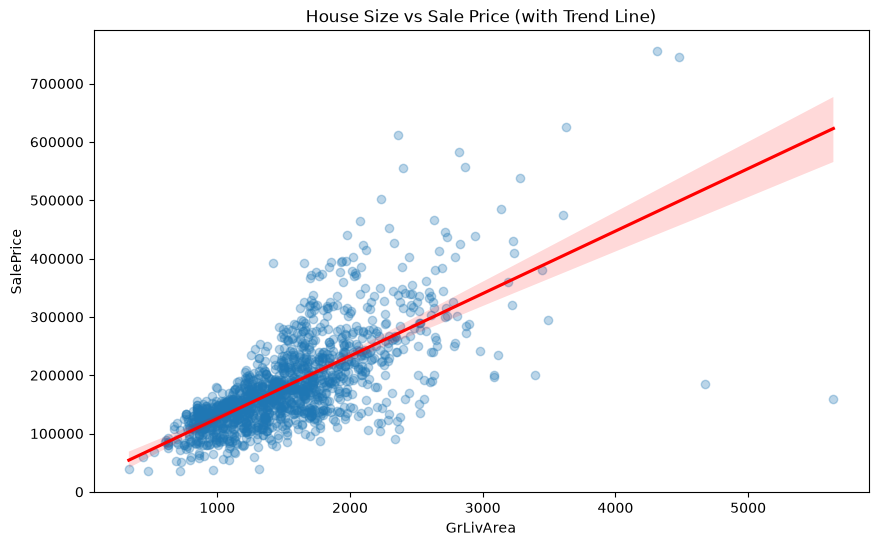

In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_house, x='GrLivArea', y='SalePrice', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('House Size vs Sale Price (with Trend Line)')
plt.show()

##4.Box Plot(catergorical Analysis)

this is used to comapare the distribution of prices across different "Quality" scores(1-10 scale).
And after observing the Boxplot chart I noticed that as quality increase, the spread" of prices gets wider. This proved that " Luxary"(Level 10)
houses have much more price variance than "Standard" (Level 5)
houses.

C:\Users\User\AppData\Local\Temp\ipykernel_17184\2136387952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_house, x='OverallQual', y='SalePrice', palette='viridis')


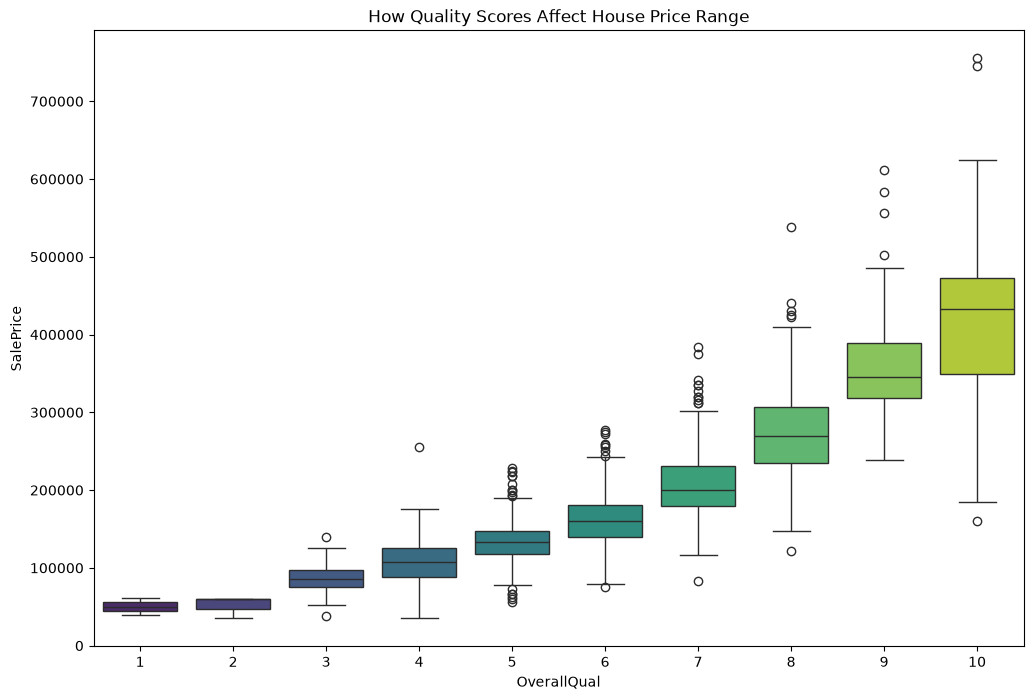

In [14]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_house, x='OverallQual', y='SalePrice', palette='viridis')
plt.title('How Quality Scores Affect House Price Range')
plt.show()


**Feature Engineering Applying**

When a buyer buys a house they check about whole Total sqare footage not about 1st or 2nd flows.

In [15]:
from ames_house_prices.features import build_features

df_house['TotalSF'] = build_features(df_house)['TotalSF']

new_corr = df_house['TotalSF'].corr(df_house['SalePrice'])
print(f"Correlation of Total Square Footage with Price: {new_corr}")

Correlation of Total Square Footage with Price: 0.782260052797984


The Machine learning model

A linear Regression model



In [16]:
from ames_house_prices.modeling import evaluate_holdout

evaluation = evaluate_holdout(df_house, random_state=42, test_size=0.2)
model = evaluation.model
Y_test = evaluation.actual
predictions = evaluation.predictions
print("Model Training Complete")

Model Training Complete


**Testing the Model:-**

guess the prices for the 20% of houses it didn't see during training

In [17]:
print(f"On average, our model's guess is off by: ${evaluation.mae:,.2f}")

On average, our model's guess is off by: $24,810.15


**Final check**

Actual vs Predicted

In [18]:
results = evaluation.results
print(results.head(5))

      Actual($)   Predicted($)  Variance(Error)($)
892      154500  147122.156559        -7377.843441
1105     325000  287518.889928       -37481.110072
413      115000  130063.256550        15063.256550
522      159000  180076.621950        21076.621950
1036     315500  295836.224926       -19663.775074


The final evaluation of the Linear Regression model demonstrates strong predictive capabilities, achieving a **Mean Absolute Error (MAE) of $24,810.15.** By focusing on four key features—Total Square Footage, Overall Quality, Year Built, and Garage Capacity—the model successfully captured the primary drivers of real estate value in the Ames dataset."

Sample Prediction Results
above is a comparison of the model's predictions against the actual sale prices for five test cases.

##Key Conclusions
* **High Reliability for Mid-Range Homes**: The model is exceptionally accurate for "standard" properties (e.g., Property 892), where the variance was only ~4.7%. This suggests that for the majority of the market, size and quality are sufficient for a reliable appraisal.

* **The Luxury Variance Gap**: The model tended to under-predict for high-end properties (e.g., Property 1105). This indicates that luxury homes likely possess "invisible" value drivers not captured in our current features, such as premium neighborhood locations, high-end interior finishes, or unique architectural designs.

* **Feature Impact**: The reduction in MAE from over $25,600 to $24,810 after adding YearBuilt and GarageCars confirms that property age and utility are critical secondary factors that refine price accuracy.

* **Actionable Insight:** With a consistent error margin of roughly 10% of the average home price, this model serves as a powerful tool for initial market valuations, providing a data-driven baseline for real estate agents and investors.

